In [1]:
import torch
import transformers

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Transformers version:", transformers.__version__)

C:\Users\Admin\miniconda3\envs\mlenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch version: 2.8.0+cu128
CUDA available: True
Transformers version: 4.44.2


In [2]:
!pip install transformers==4.44.2 peft==0.6.0


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install google-play-scraper


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### **PLAYSTORE REVIEW** ###

In [4]:
from google_play_scraper import reviews, Sort
import pandas as pd
import re, unicodedata, sys
from datetime import datetime
from indoNLP.preprocessing import replace_slang

In [5]:
df = pd.read_csv("review_raw_com.roblox.client.csv")

In [6]:
print("Total setelah filter before_date:", len(df))
if len(df) > 0:
    print("Range tanggal:", df["at"].min(), "sampai", df["at"].max())
else:
    print("Tidak ada review yang lebih tua dari 1 Okt 2025.")

Total setelah filter before_date: 20000
Range tanggal: 2025-09-18 12:22:46 sampai 2025-09-30 23:57:40


In [7]:
df.head(10)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,27687bf1-4587-444f-a0c7-5f20cda63c41,CAHYO,https://play-lh.googleusercontent.com/a/ACg8oc...,jelek tidak bisa merubah lokasi negara,2,0,2.683.775,2025-09-30 23:57:40,NaN,NaN,2.683.775
1,ed964c2c-45dc-40d7-b4be-cf11b44572ca,Zacky Rahman Jaelani,https://play-lh.googleusercontent.com/a-/ALV-U...,mantap,5,0,2.692.843,2025-09-30 23:55:48,NaN,NaN,2.692.843
2,b2f1355b-242b-46c5-9be1-2937f715d0fc,Fahmi Akbar,https://play-lh.googleusercontent.com/a/ACg8oc...,banyak gem tapi aku suka ya gem gar a den,5,0,2.691.868,2025-09-30 23:51:27,NaN,NaN,2.691.868
3,15d01385-218d-439e-9eef-6db57ae131a0,Yuni Arto,https://play-lh.googleusercontent.com/a/ACg8oc...,ini seru banget ada map banyak dan permainan s...,5,0,2.692.843,2025-09-30 23:38:10,NaN,NaN,2.692.843
4,210c7bc4-56a1-469a-beae-aaa8c8cb4726,Wagiman Man,https://play-lh.googleusercontent.com/a/ACg8oc...,"seru, asik, bikin ga kesepian biarpun main sen...",5,0,2.689.880,2025-09-30 23:38:06,NaN,NaN,2.689.880
5,ab28b18e-03ff-41db-a3fb-db099843c72d,Bon Neng,https://play-lh.googleusercontent.com/a/ACg8oc...,"game busuk bikin hp panas ,merusak kesehatan b...",1,0,NaN,2025-09-30 23:37:08,NaN,NaN,NaN
6,a7e8489d-3e7c-4696-be33-2e57ed4a2969,Jasa service panggilan AC Ali Dhanis,https://play-lh.googleusercontent.com/a-/ALV-U...,𝗿𝗼𝗯𝗹𝗼𝘅,5,0,2.692.843,2025-09-30 23:37:07,NaN,NaN,2.692.843
7,3593dba6-0b9c-4197-bf56-f057a1d3b611,MUHHAMMADAKHTARALVARO AKHTAR,https://play-lh.googleusercontent.com/a-/ALV-U...,no komen,5,0,2.692.843,2025-09-30 23:34:52,NaN,NaN,2.692.843
8,c9271f69-e052-4d31-af44-eeaf36d7c5b6,Putu Doden,https://play-lh.googleusercontent.com/a-/ALV-U...,"woii roblok, lu buat apa bikin fitur ngga bisa...",1,2,2.692.843,2025-09-30 23:31:06,NaN,NaN,2.692.843
9,061edada-608c-45e7-a92a-a168b25e7f1b,Rizky Riski,https://play-lh.googleusercontent.com/a/ACg8oc...,⭐⭐⭐⭐,4,0,2.690.721,2025-09-30 23:30:38,NaN,NaN,2.690.721


In [8]:
import re
import pandas as pd
import unicodedata

# Regex
url_re      = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
email_re    = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
mention_re  = re.compile(r"@\w+")
hashtag_re  = re.compile(r"#(\w+)")
number_re   = re.compile(r"\b\d+\b")
multi_ws_re = re.compile(r"\s+")
elong_re    = re.compile(r"(.)\1{2,}", flags=re.DOTALL)

emoji_re = re.compile(
    "[" +
    "\U0001F300-\U0001F5FF" +
    "\U0001F600-\U0001F64F" +
    "\U0001F680-\U0001F6FF" +
    "\U0001F700-\U0001F77F" +
    "\U0001F780-\U0001F7FF" +
    "\U0001F800-\U0001F8FF" +
    "\U0001F900-\U0001F9FF" +
    "\U0001FA00-\U0001FA6F" +
    "\U00002600-\U000026FF" +
    "\U00002700-\U000027BF" +
    "\U0001FA70-\U0001FAFF" +
    "]+", flags=re.UNICODE
)

# Cleaning
def clean_text(txt):
    if not isinstance(txt, str):
        txt = "" if pd.isna(txt) else str(txt)
    orig = txt

    # Metadata
    has_url = bool(url_re.search(txt))
    emoji_count = len(emoji_re.findall(txt))

    # Bersihkan noise
    txt = txt.replace("\n", " ").replace("\r", " ")
    txt = url_re.sub(" ", txt)
    txt = email_re.sub(" ", txt)
    txt = mention_re.sub(" ", txt)
    txt = hashtag_re.sub(lambda m: " " + m.group(1) + " ", txt)  
    txt = elong_re.sub(r"\1\1", txt)  
    txt = txt.lower()
    txt = replace_slang(txt)   
    txt = number_re.sub(" <num> ", txt)
    txt = re.sub(r"[<>\*\+=~\^`|]", " ", txt)
    txt = multi_ws_re.sub(" ", txt).strip()

    # Simpan hasil
    return pd.Series({
        "content_raw": orig,
        "content_clean": txt,
        "has_url": has_url,
        "emoji_count": emoji_count
    })

# Terapkan cleaning
content_info = df["content"].apply(clean_text)
df = pd.concat([df, content_info], axis=1)

# Tambahkan fitur panjang teks
df["char_len"]         = df["content_raw"].fillna("").str.len()
df["word_count"]       = df["content_raw"].fillna("").str.split().str.len()
df["clean_word_count"] = df["content_clean"].fillna("").str.split().str.len()

# Hapus duplikat dan komentar terlalu pendek
df = df.drop_duplicates(subset=["reviewId"]).reset_index(drop=True)
df_clean = df[df["clean_word_count"] >= 3].copy()

print("Jumlah review bersih:", len(df_clean))


Jumlah review bersih: 15492


In [9]:
import pandas as pd
import re

positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0].astype(str))
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0].astype(str))

print(f"Kata positif: {len(positive_lexicon):,} | Kata negatif: {len(negative_lexicon):,}")

def lexicon2label_inset(text):
    if not isinstance(text, str):
        return "unknown"
    toks = re.findall(r"\w+", text.lower())
    pos = sum(1 for t in toks if t in positive_lexicon)
    neg = sum(1 for t in toks if t in negative_lexicon)
    score = pos - neg
    if score > 0:
        return "positif"
    elif score < 0:
        return "negatif"
    else:
        return "netral"

df_clean["sentiment"] = df_clean["content_clean"].apply(lexicon2label_inset)

kolom_akhir = [
    "reviewId","userName","score","sentiment","thumbsUpCount","at",
    "reviewCreatedVersion","replyContent","repliedAt",
    "content_raw","content_clean","has_url","emoji_count",
    "char_len","word_count","clean_word_count"
]
for c in kolom_akhir:
    if c not in df_clean.columns:
        df_clean[c] = pd.NA
df_clean = df_clean[kolom_akhir]

print(df_clean["sentiment"].value_counts())

Kata positif: 3,610 | Kata negatif: 6,608
sentiment
negatif    5701
positif    5681
netral     4110
Name: count, dtype: int64


In [10]:
print("Jumlah review (awal):", len(df))
print("Jumlah review (setelah filter >=3 kata):", len(df_clean))
df_clean.head(20)

Jumlah review (awal): 20000
Jumlah review (setelah filter >=3 kata): 15492


,reviewId,userName,score,sentiment,thumbsUpCount,at,reviewCreatedVersion,replyContent,repliedAt,content_raw,content_clean,has_url,emoji_count,char_len,word_count,clean_word_count
0,27687bf1-4587-444f-a0c7-5f20cda63c41,CAHYO,2,negatif,0,2025-09-30 23:57:40,2.683.775,NaN,NaN,jelek tidak bisa merubah lokasi negara,jelek tidak bisa merubah lokasi negara,False,0,38,6,6
2,b2f1355b-242b-46c5-9be1-2937f715d0fc,Fahmi Akbar,5,positif,0,2025-09-30 23:51:27,2.691.868,NaN,NaN,banyak gem tapi aku suka ya gem gar a den,banyak gem tapi aku suka ya gem gar a den,False,0,41,10,10
3,15d01385-218d-439e-9eef-6db57ae131a0,Yuni Arto,5,positif,0,2025-09-30 23:38:10,2.692.843,NaN,NaN,ini seru banget ada map banyak dan permainan s...,ini seru banget ada map banyak dan permainan s...,False,1,50,9,9
4,210c7bc4-56a1-469a-beae-aaa8c8cb4726,Wagiman Man,5,negatif,0,2025-09-30 23:38:06,2.689.880,NaN,NaN,"seru, asik, bikin ga kesepian biarpun main sen...","seru, asik, bikin enggak kesepian biarpun main...",False,0,72,11,11
5,ab28b18e-03ff-41db-a3fb-db099843c72d,Bon Neng,1,negatif,0,2025-09-30 23:37:08,NaN,NaN,NaN,"game busuk bikin hp panas ,merusak kesehatan b...","game busuk bikin hp panas ,merusak kesehatan b...",False,0,52,8,8
8,c9271f69-e052-4d31-af44-eeaf36d7c5b6,Putu Doden,1,negatif,2,2025-09-30 23:31:06,2.692.843,NaN,NaN,"woii roblok, lu buat apa bikin fitur ngga bisa...","woii roblok, lu buat apa bikin fitur enggak bi...",False,0,171,29,29
10,f3f95348-e267-4598-955c-1072a9343273,jaya Kusumah,5,positif,0,2025-09-30 23:30:14,2.692.843,NaN,NaN,lopyuu seruuuuu bgtttt,lopyuu seru banget,False,0,22,3,3
11,0461fa98-e989-4b9d-99bb-35b674a6d0cc,enjiauliacahyani01,5,positif,0,2025-09-30 23:24:53,2.689.880,NaN,NaN,sukakk banget sama roblox💗,sukakk banget sama roblox💗,False,1,26,4,4
12,16716ac3-8b04-4d86-8aab-b90cb058c380,Elda Fitria,5,negatif,0,2025-09-30 23:15:48,2.690.721,NaN,NaN,bagus seru deh pokoknya mengisi kekosongan hid...,bagus seru deh pokoknya mengisi kekosongan hid...,False,0,52,8,8
13,0e70bd9a-14e2-43b1-85f5-d0590401e4d7,Moch Hadi Jln,4,negatif,2,2025-09-30 23:12:13,2.692.843,NaN,NaN,"tolong masalah jaringan di perbaiki lagi, seri...","tolong masalah jaringan di perbaiki lagi, seri...",False,0,201,32,32


In [11]:
import os, random, numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments, set_seed
)
set_seed(42)
# print("Torch:", torch.__version__)
# print(torch.cuda.current_device())
# print(torch.cuda.get_device_name(0))
# print(torch.cuda.is_available())

assert 'df_clean' in globals(), "df_clean belum ada. Jalankan blok labeling lexicon dulu."

df_model = df_clean[['content_clean', 'sentiment']].rename(columns={'content_clean': 'text', 'sentiment': 'label'}).copy()

# Konversi label string → numerik
label_map = {"negatif": 0, "netral": 1, "positif": 2}
df_model["label"] = df_model["label"].map(label_map)

# Hapus data yang tidak punya label
df_model = df_model.dropna(subset=["text", "label"]).reset_index(drop=True)
print("Total sampel:", len(df_model))
print("Distribusi label:", df_model["label"].value_counts().to_dict())


# -------------------------------------------------
# 1) Split data
# -------------------------------------------------
train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=42, stratify=df_model['label'])
train_df, valid_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['label'])

# -------------------------------------------------
# 2) Import Model & Tokenizer
# -------------------------------------------------
from transformers import BertTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

MODEL_NAME = "indobenchmark/indobert-lite-base-p1"  # atau p1
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME, do_lower_case=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# -------------------------------------------------
# 2.5) Dataset untuk Trainer
# -------------------------------------------------
from torch.utils.data import Dataset

def tokenize_fn(text: str):
    # kembalikan list of ints; padding dilakukan oleh DataCollatorWithPadding
    return tokenizer(text, truncation=True, max_length=256)

class DictDataset(Dataset):
    def __init__(self, df):
        self.texts  = df["text"].tolist()
        self.labels = df["label"].astype(int).tolist()
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenize_fn(self.texts[idx])        # <-- text langsung, bukan {"text": ...}
        # JANGAN konversi ke torch.tensor di sini
        enc["labels"] = self.labels[idx]          # int biasa
        return enc

train_dataset = DictDataset(train_df)
valid_dataset = DictDataset(valid_df)
test_dataset  = DictDataset(test_df)

# -------------------------------------------------
# 3) Model head klasifikasi
# -------------------------------------------------
# Class weights
USE_CLASS_WEIGHTS = True
weights = None
if USE_CLASS_WEIGHTS:
    counts = train_df['label'].value_counts().sort_index()
    N = len(train_df); num_labels = 3
    weights = torch.tensor([N/(num_labels*counts.get(i,1)) for i in range(num_labels)], dtype=torch.float)
    print("Class weights:", weights.tolist())

# -------------------------------------------------
# 4) Custom Trainer for Weight Loss
# -------------------------------------------------
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device) if self.class_weights is not None else None
        )
        loss = loss_fn(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

set_seed(42)

# -------------------------------------------------
# 4) Perbedaan fine tuning & non-fine tuning
# -------------------------------------------------
from copy import deepcopy

results = {}

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = np.argmax(preds, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
    }

def run_experiment(mode, base_model):
    print(f"\n===============================")
    print(f"   RUNNING: {mode.upper()}")
    print(f"=================================")

    model = deepcopy(base_model)

    # ------ Freeze Logic ------
    if mode == "no_finetune":
        for name, param in model.named_parameters():
            if "classifier" not in name:
                param.requires_grad = False
        lr = 1e-3
        epochs = 6
        print("MODE: NO Fine-Tuning (Frozen Transformer)\n")
    else:
        lr = 3e-5
        epochs = 3
        print("MODE: Full Fine-Tuning\n")

    args = TrainingArguments(
        output_dir=f"./indoLite-{mode}",
        learning_rate=lr,
        num_train_epochs=epochs,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        warmup_ratio=0.1,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        label_smoothing_factor=0.1,
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        report_to=[]
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        class_weights=weights
    )

    # TRAIN
    trainer.train()

    # VALIDATION
    print("\n== Validasi ==")
    valid_result = trainer.evaluate(valid_dataset)
    print(valid_result)

    # TEST
    print("\n== Test ==")
    test_result = trainer.evaluate(test_dataset)
    print(test_result)

    return {
        "valid": valid_result,
        "test": test_result,
        "model": model,
        "trainer": trainer
    }

# -------------------------------------------------
# 5) Run Models & Save Models
# -------------------------------------------------
num_labels = 3
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

results["fine_tuned"] = run_experiment("fine_tuned", base_model)
results["no_finetune"] = run_experiment("no_finetune", base_model)

# Save models
results["fine_tuned"]["model"].save_pretrained("./saved_fine_tuned")
results["no_finetune"]["model"].save_pretrained("./saved_no_finetune")

tokenizer.save_pretrained("./tokenizer")

# -------------------------------------------------
# 5) Perbandingan
# -------------------------------------------------
print("\n\n===== FINAL COMPARISON =====")
for mode, scores in results.items():
    print(f"{mode.upper()}")
    print(f"  Valid → Acc: {scores['valid']['eval_accuracy']:.4f} | F1: {scores['valid']['eval_f1']:.4f}")
    print(f"  Test  → Acc: {scores['test']['eval_accuracy']:.4f} | F1: {scores['test']['eval_f1']:.4f}")



Total sampel: 15492
Distribusi label: {0: 5701, 2: 5681, 1: 4110}


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'AlbertTokenizer'. 
The class this function is called from is 'BertTokenizer'.
C:\Users\Admin\miniconda3\envs\mlenv\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Class weights: [0.9058845043182373, 1.256527304649353, 0.9088742136955261]


Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-lite-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Admin\miniconda3\envs\mlenv\lib\site-packages\transformers\training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(



   RUNNING: FINE_TUNED
MODE: Full Fine-Tuning



...

{'eval_loss': 0.43387266993522644, 'eval_accuracy': 0.8777732956837434, 'eval_f1': 0.87847532703082, 'eval_runtime': 3.7487, 'eval_samples_per_second': 661.303, 'eval_steps_per_second': 82.696, 'epoch': 3.0}

== Test ==
{'eval_loss': 0.44502243399620056, 'eval_accuracy': 0.8689899967731526, 'eval_f1': 0.8696571502011498, 'eval_runtime': 5.1194, 'eval_samples_per_second': 605.349, 'eval_steps_per_second': 75.791, 'epoch': 3.0}

   RUNNING: NO_FINETUNE
MODE: NO Fine-Tuning (Frozen Transformer)



C:\Users\Admin\miniconda3\envs\mlenv\lib\site-packages\transformers\training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.060900,1.047494,0.533683,0.472246
2,1.000200,0.960752,0.553852,0.546886
3,0.959200,0.935544,0.539734,0.546336
4,0.950600,0.919592,0.567971,0.572504
5,0.931700,0.938344,0.541751,0.539741
6,0.919100,0.913374,0.578056,0.580138



== Validasi ==


{'eval_loss': 0.9133744239807129, 'eval_accuracy': 0.5780556676079064, 'eval_f1': 0.5801379988276585, 'eval_runtime': 4.9815, 'eval_samples_per_second': 497.637, 'eval_steps_per_second': 62.23, 'epoch': 6.0}

== Test ==
{'eval_loss': 0.9163361191749573, 'eval_accuracy': 0.5759922555663117, 'eval_f1': 0.5786379450758667, 'eval_runtime': 6.3528, 'eval_samples_per_second': 487.818, 'eval_steps_per_second': 61.076, 'epoch': 6.0}


===== FINAL COMPARISON =====
FINE_TUNED
  Valid → Acc: 0.8778 | F1: 0.8785
  Test  → Acc: 0.8690 | F1: 0.8697
NO_FINETUNE
  Valid → Acc: 0.5781 | F1: 0.5801
  Test  → Acc: 0.5760 | F1: 0.5786


Learning Curve: Fine-Tuned Model


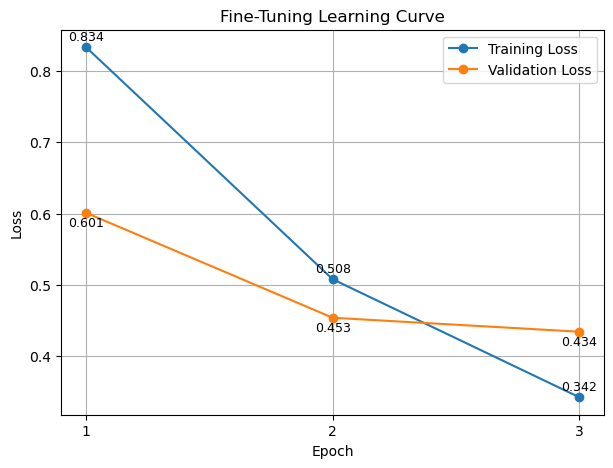


Learning Curve: No-FineTune Model


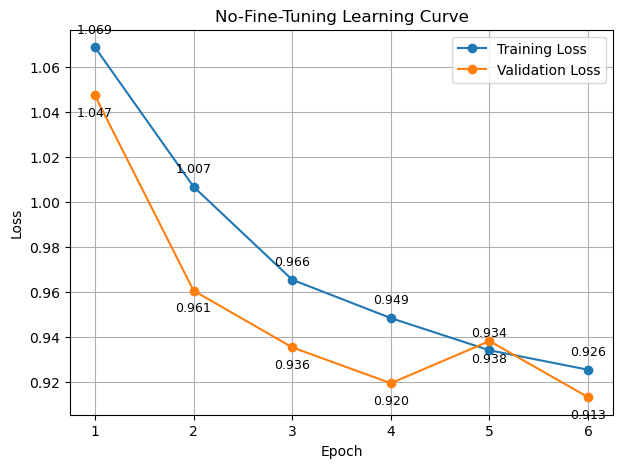

In [12]:
# -------------------------------------------------
# 5) Learning Curve
# -------------------------------------------------
import matplotlib.pyplot as plt

def plot_learning_curve(trainer, title):
    # Kumpulkan train loss per epoch
    epoch_train_losses = defaultdict(list)
    eval_epochs = []
    eval_loss = []

    for log in trainer.state.log_history:
        # log loss training
        if "loss" in log and "epoch" in log and "eval_loss" not in log:
            # epoch float → kita petakan ke epoch bulat (ceil)
            ep = int(np.ceil(log["epoch"]))
            epoch_train_losses[ep].append(log["loss"])

        # log loss validasi
        if "eval_loss" in log and "epoch" in log:
            ep = int(round(log["epoch"]))
            eval_epochs.append(ep)
            eval_loss.append(log["eval_loss"])

    # rata-rata train loss per epoch
    train_epochs = sorted(epoch_train_losses.keys())
    train_loss = [np.mean(epoch_train_losses[ep]) for ep in train_epochs]
    
    # batasi eval ke jumlah epoch (buang eval tambahan: validasi/test setelah training)
    eval_epochs = eval_epochs[:len(train_epochs)]
    eval_loss = eval_loss[:len(train_epochs)]

    plt.figure(figsize=(7,5))
    plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
    plt.plot(eval_epochs, eval_loss, marker="o", label="Validation Loss")

    # Tambah angka di setiap titik Training Loss
    for x, y in zip(train_epochs, train_loss):
        plt.text(x, y + 0.005, f"{y:.3f}", ha="center", va="bottom", fontsize=9)

    # Tambah angka di setiap titik Validation Loss 
    for x, y in zip(eval_epochs, eval_loss):
        plt.text(x, y - 0.005, f"{y:.3f}", ha="center", va="top", fontsize=9)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(train_epochs) 
    plt.grid(True)
    plt.legend()
    plt.show()

print("Learning Curve: Fine-Tuned Model")
plot_learning_curve(results["fine_tuned"]["trainer"], "Fine-Tuning Learning Curve")

print("\nLearning Curve: No-FineTune Model")
plot_learning_curve(results["no_finetune"]["trainer"], "No-Fine-Tuning Learning Curve")

In [13]:
# ==========================================
# 6) INFERENCE & CLASSIFICATION REPORT
# ==========================================

print("\n\n===== INFERENCE & EVALUASI MODEL =====\n")

label_map = {0:"negatif", 1:"netral", 2:"positif"}

def predict(model, texts):
    model.eval()
    enc = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        logits = model(**enc).logits

    preds = logits.argmax(dim=1).cpu().numpy().tolist()
    return [label_map[i] for i in preds]

contoh = [
    "Game-nya jelek aku gak suka",
    "Lumayan seru, tapi kontrol agak susah",
    "Mantap banget! Grafiknya bagus",
    "Gamenya keren, aku suka banget!"
]

print("\n>> Prediksi Menggunakan Fine-Tuned Model:")
print(list(zip(contoh, predict(results['fine_tuned']['model'], contoh))))

print("\n>> Prediksi Menggunakan No-FineTune Model:")
print(list(zip(contoh, predict(results['no_finetune']['model'], contoh))))


# -------------------------------------------------
# Classification Report di Test Set
# -------------------------------------------------
from sklearn.metrics import classification_report

def evaluate_report(model_name, trainer_obj):
    preds = np.argmax(trainer_obj.predict(test_dataset).predictions, axis=1)
    print(f"\n===== Classification Report ({model_name}) =====")
    print(classification_report(test_df['label'],preds,target_names=[label_map[i] for i in range(num_labels)]))


evaluate_report("Fine-Tuned Model",   results['fine_tuned']["trainer"])
evaluate_report("No-FineTune Model", results['no_finetune']["trainer"])




===== INFERENCE & EVALUASI MODEL =====


>> Prediksi Menggunakan Fine-Tuned Model:
[('Game-nya jelek aku gak suka', 'netral'), ('Lumayan seru, tapi kontrol agak susah', 'negatif'), ('Mantap banget! Grafiknya bagus', 'positif'), ('Gamenya keren, aku suka banget!', 'positif')]

>> Prediksi Menggunakan No-FineTune Model:
[('Game-nya jelek aku gak suka', 'netral'), ('Lumayan seru, tapi kontrol agak susah', 'negatif'), ('Mantap banget! Grafiknya bagus', 'positif'), ('Gamenya keren, aku suka banget!', 'positif')]

===== Classification Report (Fine-Tuned Model) =====
              precision    recall  f1-score   support

     negatif       0.91      0.89      0.90      1141
      netral       0.77      0.80      0.78       822
     positif       0.91      0.90      0.90      1136

    accuracy                           0.87      3099
   macro avg       0.86      0.86      0.86      3099
weighted avg       0.87      0.87      0.87      3099


===== Classification Report (No-FineTune Model) =

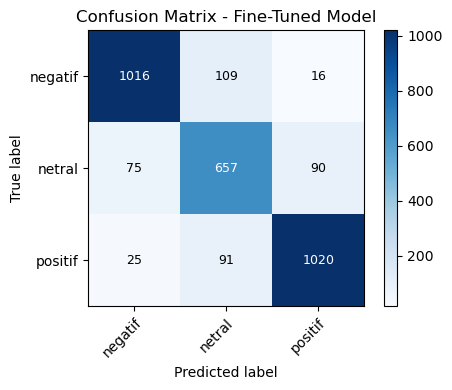

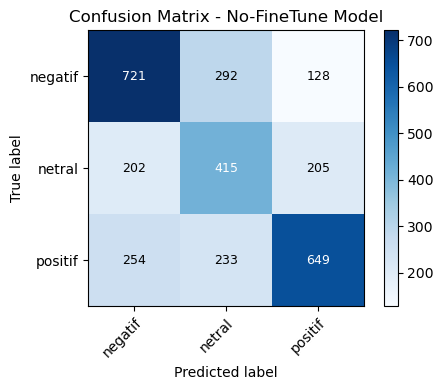

In [14]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model_name, trainer_obj):
    # Prediksi di test set
    y_true = test_df["label"].values
    y_pred = np.argmax(trainer_obj.predict(test_dataset).predictions, axis=1)

    # Hitung confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_labels)))

    # Plot
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    kelas = [label_map[i] for i in range(num_labels)]
    ax.set(
        xticks=np.arange(len(kelas)),
        yticks=np.arange(len(kelas)),
        xticklabels=kelas,
        yticklabels=kelas,
        xlabel="Predicted label",
        ylabel="True label",
        title=f"Confusion Matrix - {model_name}",
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Tampilkan angka di setiap sel
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=9
            )

    fig.tight_layout()
    plt.show()

plot_confusion_matrix("Fine-Tuned Model",   results['fine_tuned']["trainer"])
plot_confusion_matrix("No-FineTune Model", results['no_finetune']["trainer"])